<html> <h1 style="font-style:bold; color:blue;"> Neural Computing and Deep Learning </h1> </html>

<html> <h1 style="font-style:italic; color:blue;"> Week-6 </h1> </html>

<html> <h2 style="font-style:italic; color:blue;"> RNN for Time Series </h2> </html>


RNNs are used for sequence modelling. This tutorial will look at time series data to be modelled and predicted using RNNs. 

In [1]:
# Import Libraries (pandas, numpy, matplotlib)

# ....
# ...
# ...


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Data

We will use retail data for time-series modeling. 

Link to the dataset:
 https://fred.stlouisfed.org/series/MRTSSM448USN

Information about the Advance Monthly Retail Sales Survey can be found on the Census website at:
https://www.census.gov/retail/marts/about_the_surveys.html

Release: Advance Monthly Sales for Retail and Food Services  
Units:  Millions of Dollars, Not Seasonally Adjusted
Frequency:  Monthly

Suggested Citation:
U.S. Census Bureau, Advance Retail Sales: Clothing and Clothing Accessory Stores [RSCCASN], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/RSCCASN, January 25, 2025.



##### Read data first -  Use index_col = 'DATE' and 'parse_dates = True' as a parameter.

_________________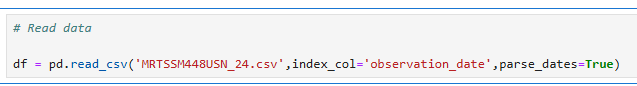

In [2]:
df = pd.read_csv(r"C:\Users\10hit\OneDrive\Desktop\Course_work\Neural-Computing-and-Deep-Learning-2025-MOD006568-TRI2-F01CAM-\course_work\MRTSSM448USN_24-1.csv", index_col='observation_date', parse_dates=True)

In [4]:
#pd.read_csv

In [3]:
# Print the first few rows of data
#d
# ...
df.head()

,MRTSSM448USN
observation_date,
1992-01-01,6938
1992-02-01,7524
1992-03-01,8475
1992-04-01,9401
1992-05-01,9558


_______________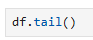

In [4]:
df.tail()

,MRTSSM448USN
observation_date,
2024-08-01,27215
2024-09-01,23088
2024-10-01,25318
2024-11-01,29762
2024-12-01,41199


Does the sales column has any name?

If no, set the name of the colum as 'Sales'.

In [5]:
# Set name of column as 'Sales'. Use - df.columns 

# ...
df.columns = ['Sales']
df.head()

,Sales
observation_date,
1992-01-01,6938
1992-02-01,7524
1992-03-01,8475
1992-04-01,9401
1992-05-01,9558


Plot your data - Year vs Sales

hint: use df.plot  and plt.show()

____________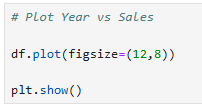

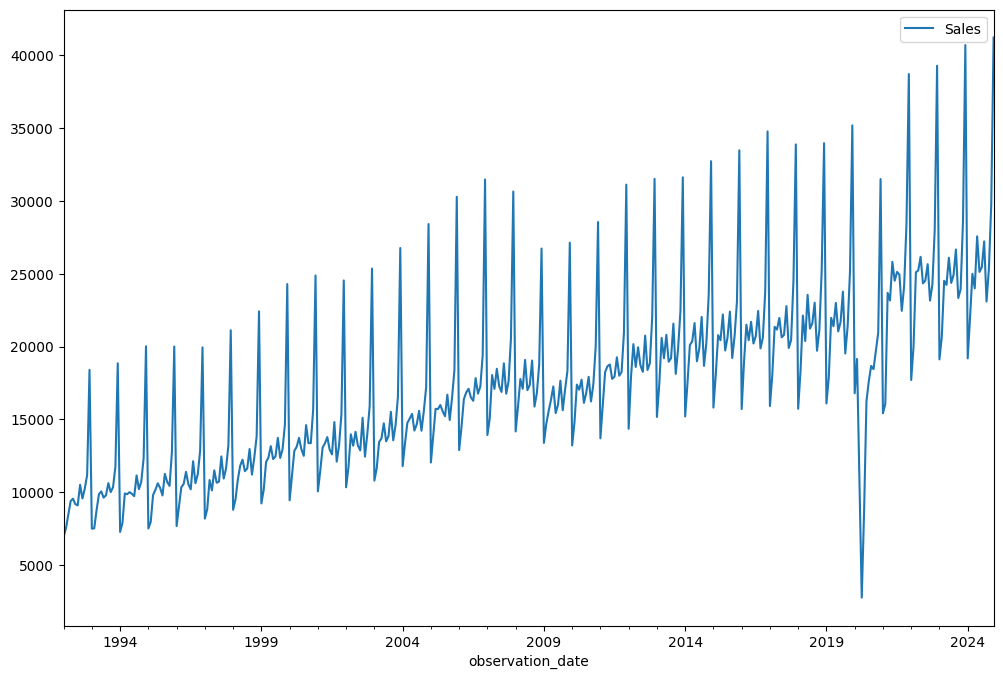

In [6]:
df.plot(figsize=(12,8))

plt.show()

### Train Test Split 

We will use the last 1.5 years (18 months) samples for testing. The rest is for training

______________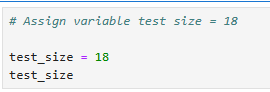

In [7]:
test_size = 18
test_size

18

__________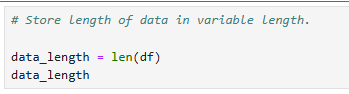

In [8]:
data_length = len(df)

__________________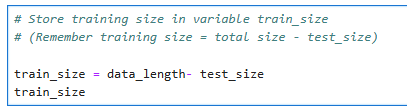

In [9]:
train_size = data_length - test_size
train_size

378

Now, we will find the indexes of the test data. Remember, these are the last 18 indexes in the pandas dataframe.

____________________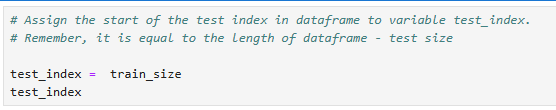

In [10]:
test_index = train_size
test_index

378

Next, we will separate train and test datasets.

_________________________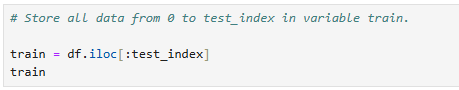

In [11]:
train = df.iloc[:test_index]
train

,Sales
observation_date,
1992-01-01,6938
1992-02-01,7524
1992-03-01,8475
1992-04-01,9401
1992-05-01,9558
...,...
2023-02-01,20666
2023-03-01,24510
2023-04-01,24232


In [12]:
# Store everything from test_index to the last sample in the test variable 
# Hint - Use df.iloc

# ...
# ...
test = df.iloc[test_index:]
test

,Sales
observation_date,
2023-07-01,24911
2023-08-01,26657
2023-09-01,23332
2023-10-01,23933
2023-11-01,28580
2023-12-01,40684
2024-01-01,19188
2024-02-01,22005
2024-03-01,24986


In [13]:
# Print the size of the train data

# ...

# Print the size of the test data

# ...
print(train.shape[0])
print(test.shape[0])

378
18


### In Neural Networks, we need to Scale Data between 0-1

___________________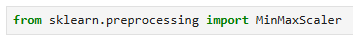

In [14]:
from sklearn.preprocessing import MinMaxScaler

_______________________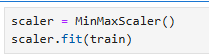

In [15]:
scaler = MinMaxScaler()
scaler.fit(train)

,feature_range,"(0, ...)"
,copy,True
,clip,False


__________________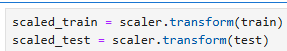

In [16]:
scaled_train = scaler.transform(train)
scaled_test = scaler.transform(test)

In [17]:
# Check if the data has been scaled properly
# Print max and min for train and test

# ...
# ...
# ...
# ...
print(scaled_train.max())
print(scaled_train.min())
print(scaled_test.max())
print(scaled_test.min())

1.0
0.0
1.0530599939704552
0.44980403979499545


## Time Series Generator

This class takes in a sequence of data points gathered at
equal intervals, along with time series parameters such as
stride, length of history, etc., to produce batches for
training/validation.

#### Arguments
    data: Indexable generator (such as list or Numpy array)
        containing consecutive data points (timesteps).
        The data should be at 2D, and axis 0 is expected
        to be the time dimension.
    targets: Targets corresponding to timesteps in `data`.
        It should have same length as `data`.
    length: Length of the output sequences (in number of timesteps).
    sampling_rate: Period between successive individual timesteps
        within sequences. For rate `r`, timesteps
        `data[i]`, `data[i-r]`, ... `data[i - length]`
        are used for create a sample sequence.
    stride: Period between successive output sequences.
        For stride `s`, consecutive output samples would
        be centered around `data[i]`, `data[i+s]`, `data[i+2*s]`, etc.
    start_index: Data points earlier than `start_index` will not be used
        in the output sequences. This is useful to reserve part of the
        data for test or validation.
    end_index: Data points later than `end_index` will not be used
        in the output sequences. This is useful to reserve part of the
        data for test or validation.
    shuffle: Whether to shuffle output samples,
        or instead draw them in chronological order.
    reverse: Boolean: if `true`, timesteps in each output sample will be
        in reverse chronological order.
    batch_size: Number of timeseries samples in each batch
        (except maybe the last one).

### We will use 12 months as input and then predict the next month out


_____________________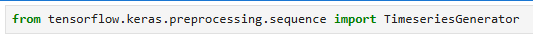

In [18]:
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

In [ ]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [ ]:
#TimeseriesGenerator?

_________________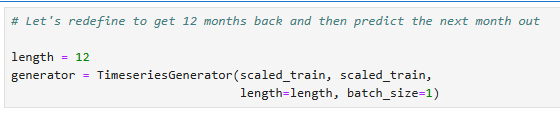

In [19]:
length = 12
generator = TimeseriesGenerator(scaled_train, scaled_train,
                                length=length, batch_size=1)

_______________________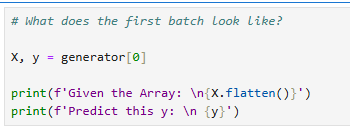

In [20]:
X, y = generator[0]

print(f'given the Array: \n{X.flatten()}')
print(f'Predict this y: \n {y}')

given the Array: 
[0.11406802 0.13012854 0.15619262 0.18157152 0.18587442 0.17556938
 0.17340423 0.21204813 0.18628553 0.20494971 0.23052046 0.42807027]
Predict this y: 
 [[0.12952558]]


### Create the Model

__________________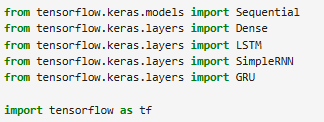

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, Dropout, BatchNormalization
import tensorflow as tf

________________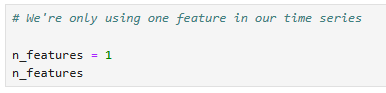

In [22]:
n_features = 1
n_features

1

## Define your own models. 

Use 1. SimpleRNN, LSTM, or GRU neural network.

APIs:
https://keras.io/api/layers/recurrent_layers/

In [23]:
# Your code to create your own model
# use input_shape=(length, n_features)
# use model.add(Dense(1)) because it is the regression task
 
# .....
# .....
# .....
model = Sequential()

model.add(LSTM(150, activation='relu', return_sequences=True, input_shape=(length, n_features)))
model.add(LSTM(70, activation='relu', return_sequences=True))
model.add(LSTM(30, activation='relu'))

model.add(Dense(1))
               

c:\Users\10hit\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [24]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 150)        │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 12, 70)         │        61,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 30)             │        12,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165,231 (645.43 KB)

 Trainable params: 165,231 (645.43 KB)

 Non-trainable params: 0 (0.00 B)

_____________________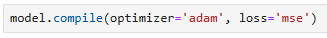

In [25]:
model.compile(optimizer='adamW', loss='mse')

### EarlyStopping and creating a Validation Generator

NOTE: The scaled_test dataset size MUST be greater than your length chosen for your batches. 

Review the video on the Week-6 page for more info on this.

____________________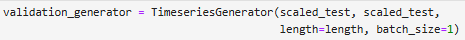

In [26]:
validation_generator = TimeseriesGenerator(scaled_test, scaled_test,
                                           length=length, batch_size=1)

___________________

In [27]:
from tensorflow.keras.callbacks import EarlyStopping

In [28]:
# Your code to create an object early-stop

# Use the patience parameter equal to the last digit in your SID.
# However,
# If the last digit of your SID = 0, then assign patience=10
# If the last digit of your SID = 1, then assign patience=11
# If the last digit of your SID = 2, then assign patience=12
# If the last digit of your SID = 3, then assign patience=13

# For example, your SID = 22984879, then patience=9
# One more example: your SID = 22984883, then patience=13

LAST_DIGIT_IN_YOUR_SID = 12

early_stop = EarlyStopping(monitor='val_loss',patience=LAST_DIGIT_IN_YOUR_SID)


_____________________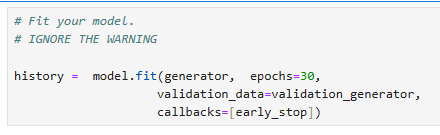

In [29]:
history = model.fit(generator, epochs=30,
                    validation_data=validation_generator,
                    callbacks=[early_stop])

Epoch 1/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0208 - val_loss: 0.0700
Epoch 2/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0123 - val_loss: 0.0078
Epoch 3/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0093 - val_loss: 0.0086
Epoch 4/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0066 - val_loss: 0.0075
Epoch 5/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0060 - val_loss: 0.0013
Epoch 6/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0051 - val_loss: 0.0090
Epoch 7/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0052 - val_loss: 3.9320e-04
Epoch 8/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0042 - val_loss: 0.0025
Epoch 9/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0049 - val_loss: 4.3707e-04
Epoch 10/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0045 - val_loss: 0.0019
Epoch 11/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0038 - val_loss: 0.0027
Epoch 12/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 

_____________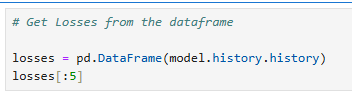

In [30]:
losses = pd.DataFrame(model.history.history)
losses[:5]

,loss,val_loss
0,0.020830,0.069960
1,0.012320,0.007761
2,0.009309,0.008574
3,0.006610,0.007465
4,0.005984,0.001254


In [ ]:
# the values may be different


___________________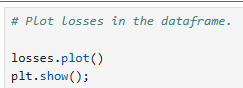

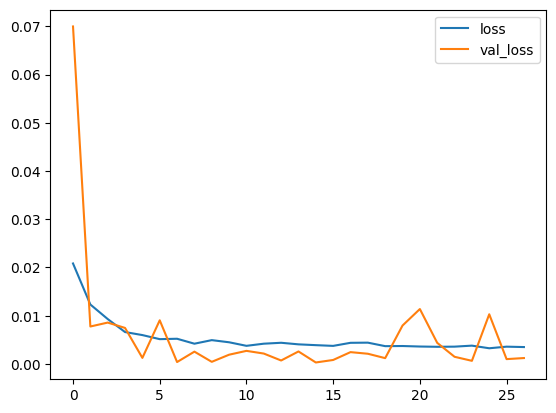

In [31]:
losses.plot()
plt.show();

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

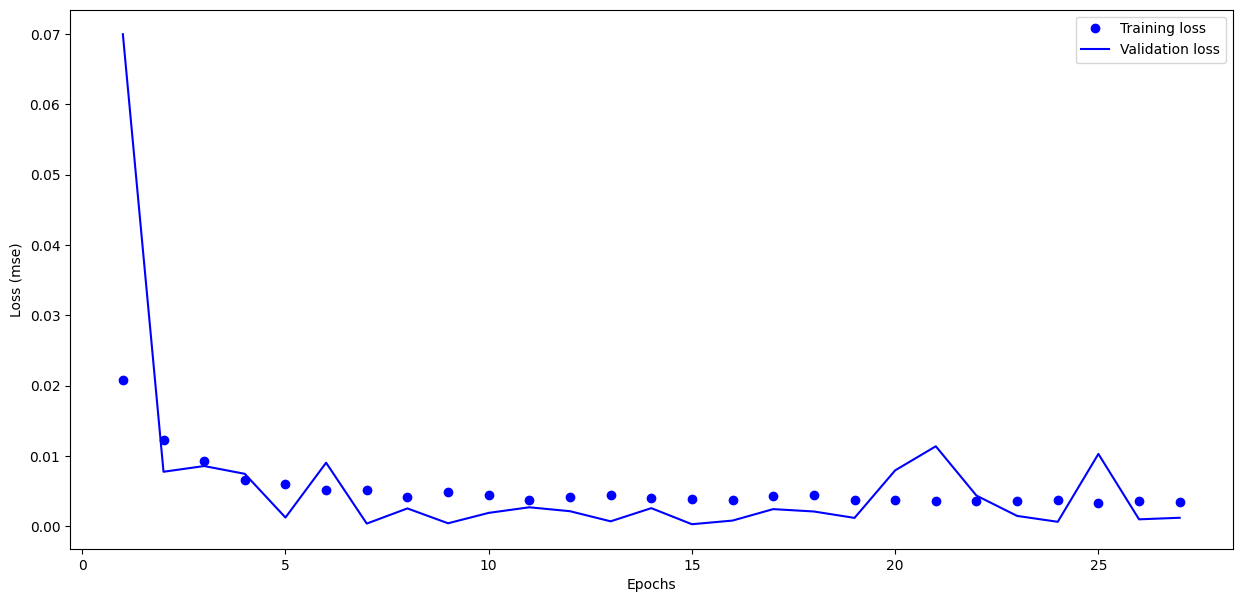

In [32]:
# print Loss for the neural network training process

history_dict = history.history

acc_values = history_dict['loss']
val_acc_values = history_dict['val_loss']
epochs = range(1, len(acc_values) + 1)

plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, acc_values, 'bo', label='Training loss')
plt.plot(epochs, val_acc_values, 'b', label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (mse)')
plt.legend()

plt.show()

### Evaluate on Test Data

____________________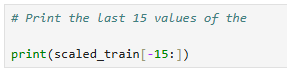

In [33]:
print(scaled_train[-15:])

[[0.61523282]
 [0.64077617]
 [0.5909502 ]
 [0.59621235]
 [0.62693562]
 [0.55844547]
 [0.58834653]
 [0.69254803]
 [1.        ]
 [0.44788555]
 [0.49031162]
 [0.59566421]
 [0.58804506]
 [0.63913175]
 [0.59166278]]


____________________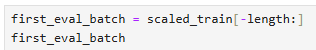

In [34]:
first_eval_batch = scaled_train[-length:]
first_eval_batch

array([[0.59621235],
       [0.62693562],
       [0.55844547],
       [0.58834653],
       [0.69254803],
       [1.        ],
       [0.44788555],
       [0.49031162],
       [0.59566421],
       [0.58804506],
       [0.63913175],
       [0.59166278]])

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [35]:
n_input = 12
first_eval_batch = first_eval_batch.reshape((1, n_input, n_features))
first_eval_batch

array([[[0.59621235],
        [0.62693562],
        [0.55844547],
        [0.58834653],
        [0.69254803],
        [1.        ],
        [0.44788555],
        [0.49031162],
        [0.59566421],
        [0.58804506],
        [0.63913175],
        [0.59166278]]])

___________________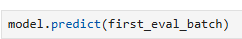

In [36]:
model.predict(first_eval_batch)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step


array([[0.57503235]], dtype=float32)

_________________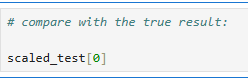

In [37]:
scaled_test[0]

array([0.60665442])

#### Try predicting the series!

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [38]:
test_predictions = []

first_eval_batch = scaled_train[-length:]
current_batch = first_eval_batch.reshape((1, length, n_features))

current_batch

array([[[0.59621235],
        [0.62693562],
        [0.55844547],
        [0.58834653],
        [0.69254803],
        [1.        ],
        [0.44788555],
        [0.49031162],
        [0.59566421],
        [0.58804506],
        [0.63913175],
        [0.59166278]]])

____________________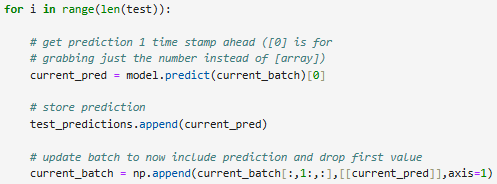

In [39]:
for i in range(len(test)):
    current_pred = model.predict(current_batch)[0]
    test_predictions.append(current_pred)
    current_batch = np.append(current_batch[:,1:,:],[[current_pred]],axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


______________________

In [40]:
test_predictions

[array([0.57503235], dtype=float32),
 array([0.6031341], dtype=float32),
 array([0.55312496], dtype=float32),
 array([0.57491785], dtype=float32),
 array([0.69774544], dtype=float32),
 array([0.97922087], dtype=float32),
 array([0.47882426], dtype=float32),
 array([0.51434255], dtype=float32),
 array([0.57530594], dtype=float32),
 array([0.56726456], dtype=float32),
 array([0.61317074], dtype=float32),
 array([0.5711937], dtype=float32),
 array([0.559275], dtype=float32),
 array([0.5821054], dtype=float32),
 array([0.54770815], dtype=float32),
 array([0.5652962], dtype=float32),
 array([0.6944598], dtype=float32),
 array([0.96637064], dtype=float32)]

### Inverse Transformations and Compare

_________________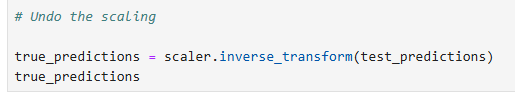

In [41]:
true_predictions = scaler.inverse_transform(test_predictions)
true_predictions

array([[23757.20547855],
       [24782.55374867],
       [22957.87057012],
       [23753.02769798],
       [28234.6379565 ],
       [38504.83177996],
       [20246.8606962 ],
       [21542.8164928 ],
       [23767.1877861 ],
       [23473.78188705],
       [25148.76089942],
       [23617.14435196],
       [23182.26588458],
       [24015.27966332],
       [22760.22740495],
       [23401.96146774],
       [28114.75457489],
       [38035.96562141]])

_____________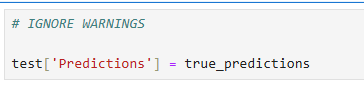

In [43]:
test['Predictions'] = true_predictions

C:\Users\10hit\AppData\Local\Temp\ipykernel_16484\4269337381.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Predictions'] = true_predictions


### Check and plot predictions

In [44]:
# Print the test variable

# ...
print(test)

                  Sales   Predictions
observation_date                     
2023-07-01        24911  23757.205479
2023-08-01        26657  24782.553749
2023-09-01        23332  22957.870570
2023-10-01        23933  23753.027698
2023-11-01        28580  28234.637957
2023-12-01        40684  38504.831780
2024-01-01        19188  20246.860696
2024-02-01        22005  21542.816493
2024-03-01        24986  23767.187786
2024-04-01        23993  23473.781887
2024-05-01        27562  25148.760899
2024-06-01        25121  23617.144352
2024-07-01        25453  23182.265885
2024-08-01        27215  24015.279663
2024-09-01        23088  22760.227405
2024-10-01        25318  23401.961468
2024-11-01        29762  28114.754575
2024-12-01        41199  38035.965621


_______________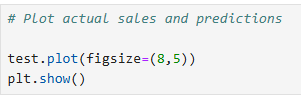

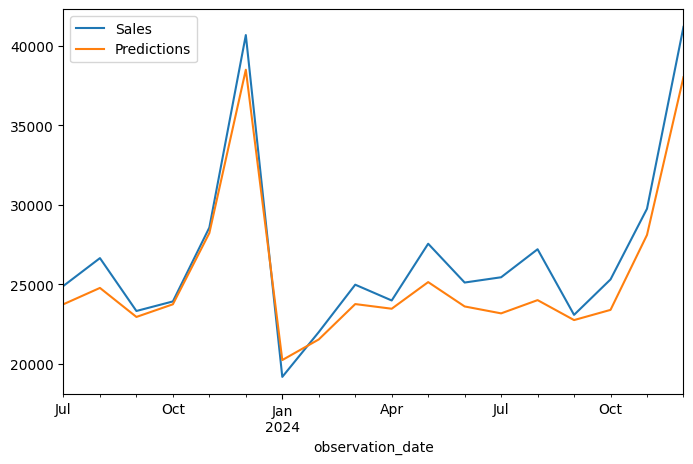

In [45]:
test.plot(figsize=(8,5))
plt.show()

### Retrain and Forecasting

_________________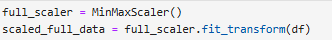

In [46]:
full_scaler = MinMaxScaler()
Scaled_full_data = full_scaler.fit_transform(df)

______________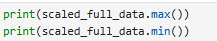

In [47]:
print(Scaled_full_data.max())
print(Scaled_full_data.min())

1.0
0.0


<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [48]:
length = 12 # Length of the output sequences (in number of timesteps)
generator = TimeseriesGenerator(Scaled_full_data, 
                                Scaled_full_data, length=length, batch_size=1)

In [ ]:
# Use any neural network model based on RNN
# You can also use the model created above
#
# Create the model

# ...
# ...
# ...
model_2 = Sequential()

model_2.add(GRU(200, activation='relu', return_sequences=True, input_shape=(length, n_features)))
model_2.add(GRU(100, activation='relu', return_sequences=True))
model_2.add(GRU(50, activation='relu', return_sequences=True))
model_2.add(GRU(20, activation='relu'))

model_2.add(Dense(1))


c:\Users\10hit\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [50]:
model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 12, 200)        │       121,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 12, 100)        │        90,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 12, 50)         │        22,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 20)             │         4,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 239,541 (935.71 KB)

 Trainable params: 239,541 (935.71 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:
# your code to compile the model

# ...
model_2.compile(optimizer='adamW', loss='mse')

In [52]:
# Your code to create an object early-stop

# Use the patience parameter equal to the last digit in your SID.
# However,
# If the last digit of your SID = 0, then assign patience=10
# If the last digit of your SID = 1, then assign patience=11
# If the last digit of your SID = 2, then assign patience=12
# If the last digit of your SID = 3, then assign patience=13

# For example, your SID = 22984879, then patience=9
# One more example: your SID = 22984883, then patience=13

LAST_DIGIT_IN_YOUR_SID = 12

early_stop = EarlyStopping(monitor='val_loss',patience=LAST_DIGIT_IN_YOUR_SID)


____________________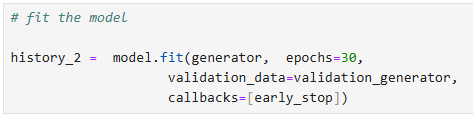

In [53]:
history_2 = model_2.fit(generator, epochs=30, validation_data=validation_generator, callbacks=[early_stop])

Epoch 1/30


384/384 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 0.0224 - val_loss: 0.0961
Epoch 2/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0131 - val_loss: 0.0162
Epoch 3/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0091 - val_loss: 0.0280
Epoch 4/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0057 - val_loss: 0.0020
Epoch 5/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0041 - val_loss: 0.0190
Epoch 6/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.0046 - val_loss: 0.0047
Epoch 7/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0040 - val_loss: 0.0013
Epoch 8/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0040 - val_loss: 0.0047
Epoch 9/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0041 - val_loss: 8.7687e-04
Epoch 10/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0040 - val_loss: 0.0023
Epoch 11/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0039 - val_loss: 5.4747e-04
Epoch 12/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 6s

In [54]:
# fit the model

history_2 =  model.fit(generator,  epochs=30,
                    validation_data=validation_generator,
                    callbacks=[early_stop])

Epoch 1/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0027 - val_loss: 0.0014
Epoch 2/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0029 - val_loss: 0.0053
Epoch 3/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0030 - val_loss: 0.0100
Epoch 4/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0029 - val_loss: 4.9169e-04
Epoch 5/30
 53/384 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 9.8346e-04

KeyboardInterrupt: 

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

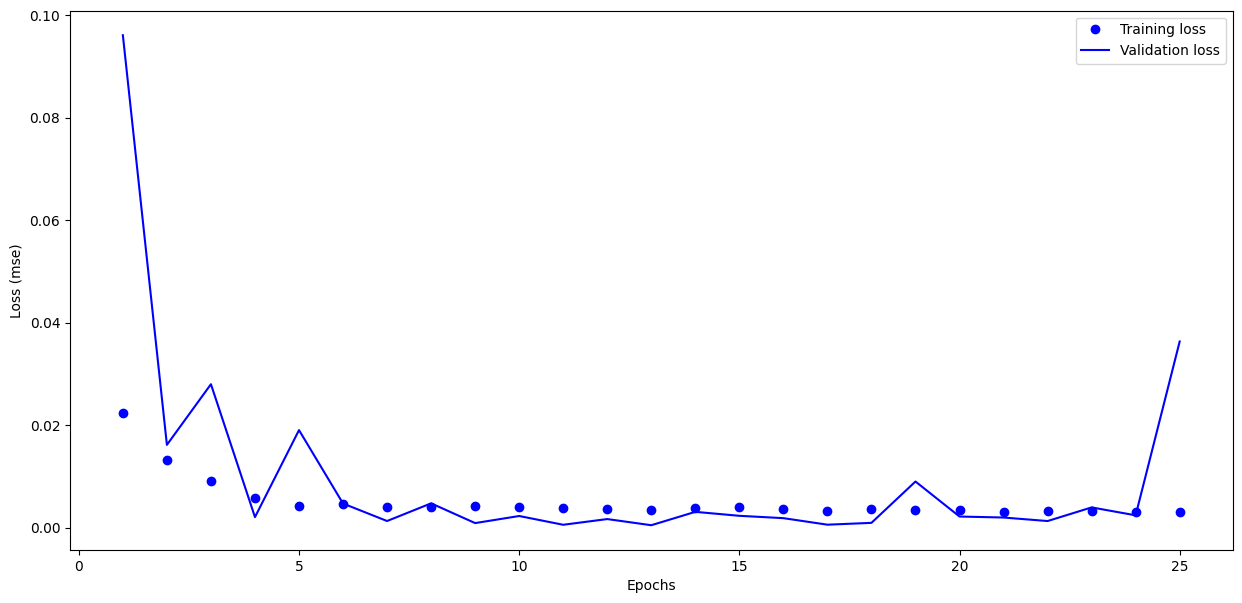

In [55]:
# print Loss for the neural network training process

history_dict = history_2.history

acc_values = history_dict['loss']
val_acc_values = history_dict['val_loss']
epochs = range(1, len(acc_values) + 1)

plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, acc_values, 'bo', label='Training loss')
plt.plot(epochs, val_acc_values, 'b', label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (mse)')
plt.legend()

plt.show()

In [ ]:
# You can use the code created above to type the next cell code

_________________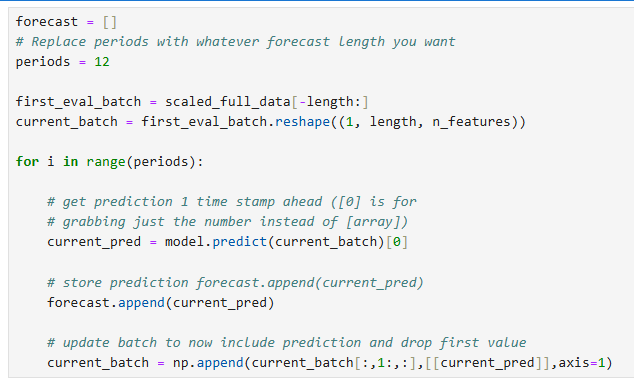

In [56]:
forecast = []
periods = 12

first_eval_batch = Scaled_full_data[-length:]
current_batch = first_eval_batch.reshape((1, length, n_features))

for i in range(periods):
    current_pred = model.predict(current_batch)[0]
    forecast.append(current_pred)
    current_batch = np.append(current_batch[:,1:,:],[[current_pred]], axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


______________________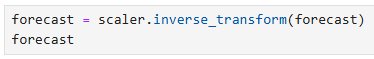

In [57]:
forecast = scaler.inverse_transform(forecast)
forecast 

array([[20451.6774216 ],
       [22625.20527762],
       [25085.68097991],
       [24212.48786956],
       [27757.91861439],
       [25142.14299923],
       [25447.76689476],
       [27492.39140826],
       [23889.88752681],
       [25677.16206217],
       [30738.63782459],
       [39252.24781513]])

### Creating new timestamp index with pandas.

<html> <h4 style="font-style:italic; color:blue;"> Just run the 4 next cells using 'Ctrl' + 'Enter' </h4> </html>

In [58]:
df

,Sales
observation_date,
1992-01-01,6938
1992-02-01,7524
1992-03-01,8475
1992-04-01,9401
1992-05-01,9558
...,...
2024-08-01,27215
2024-09-01,23088
2024-10-01,25318


##### Forecast for next 12 months

__________________

In [60]:
forecast_index = pd.date_range(start='2025-01-01',periods=periods,freq='MS')
forecast_index

DatetimeIndex(['2025-01-01', '2025-02-01', '2025-03-01', '2025-04-01',
               '2025-05-01', '2025-06-01', '2025-07-01', '2025-08-01',
               '2025-09-01', '2025-10-01', '2025-11-01', '2025-12-01'],
              dtype='datetime64[ns]', freq='MS')

__________________________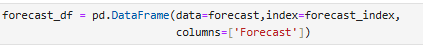

In [61]:
forecast_df = pd.DataFrame(data=forecast, index=forecast_index,
                           columns=['Forecast'])

________________________

In [62]:
forecast_df

,Forecast
2025-01-01,20451.677422
2025-02-01,22625.205278
2025-03-01,25085.680980
2025-04-01,24212.487870
2025-05-01,27757.918614
2025-06-01,25142.142999
2025-07-01,25447.766895
2025-08-01,27492.391408
2025-09-01,23889.887527
2025-10-01,25677.162062


__________________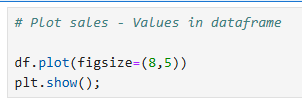

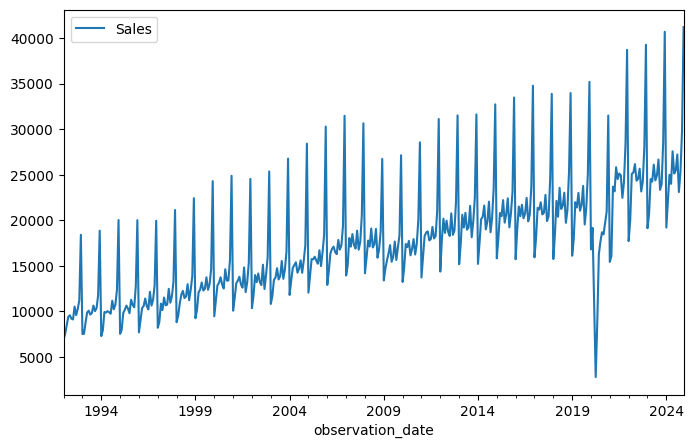

In [63]:
df.plot(figsize=(8,5))
plt.show();

____________________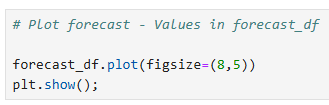

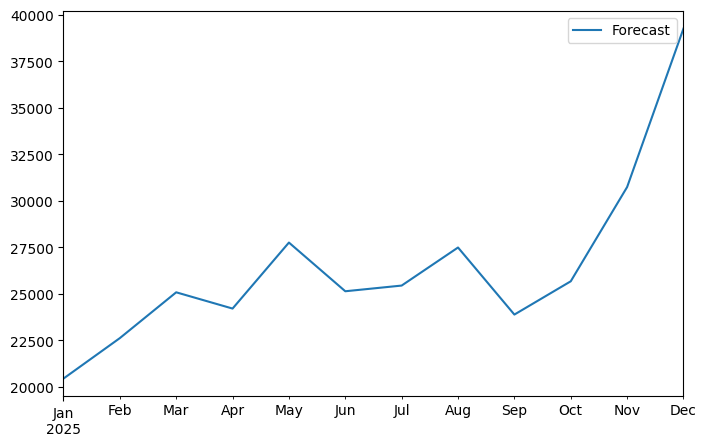

In [64]:
forecast_df.plot(figsize=(8,5))
plt.show();

### Joining pandas plots

https://stackoverflow.com/questions/13872533/plot-different-dataframes-in-the-same-figure

________________________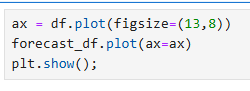

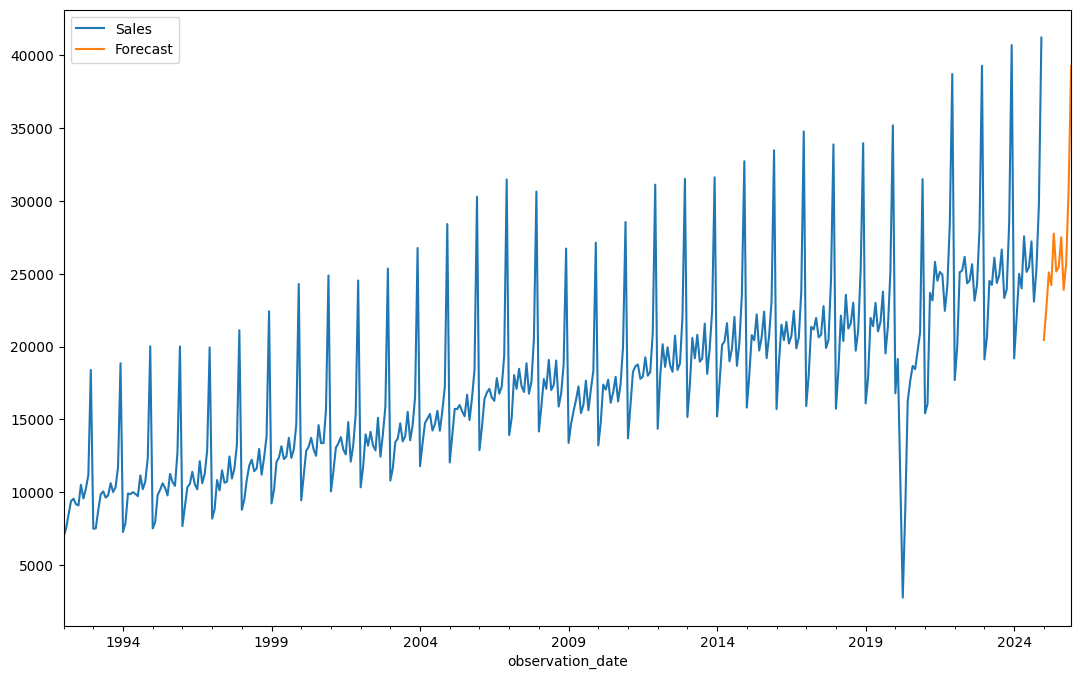

In [65]:
ax = df.plot(figsize=(13,8))
forecast_df.plot(ax=ax)
plt.show();

_______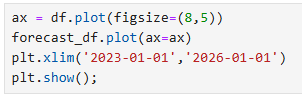

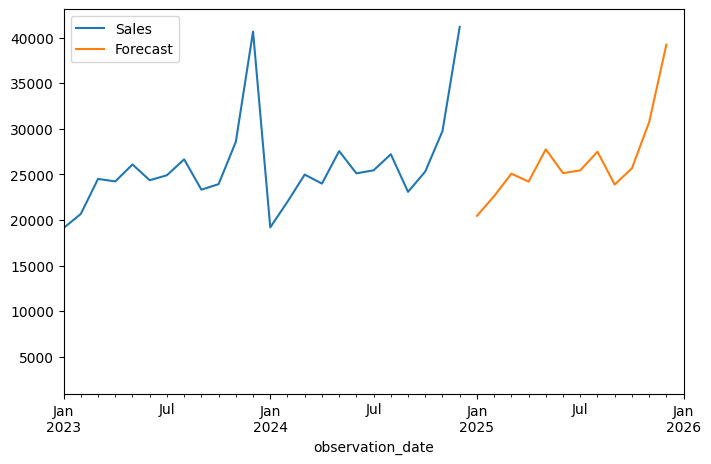

In [66]:
ax = df.plot(figsize=(8,5))
forecast_df.plot(ax=ax)
plt.xlim('2023-01-01','2026-01-01')
plt.show();

### Checking Forecast for last 12 months

_______________________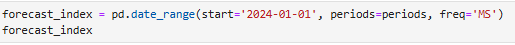

In [67]:
forecast_index = pd.date_range(start='2024-01-01', periods=periods, freq='MS')
forecast_index

DatetimeIndex(['2024-01-01', '2024-02-01', '2024-03-01', '2024-04-01',
               '2024-05-01', '2024-06-01', '2024-07-01', '2024-08-01',
               '2024-09-01', '2024-10-01', '2024-11-01', '2024-12-01'],
              dtype='datetime64[ns]', freq='MS')

________________________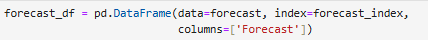

In [68]:
forecast_df = pd.DataFrame(data=forecast, index=forecast_index,
                           columns=['Forecast'])

___________________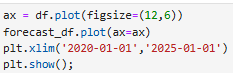

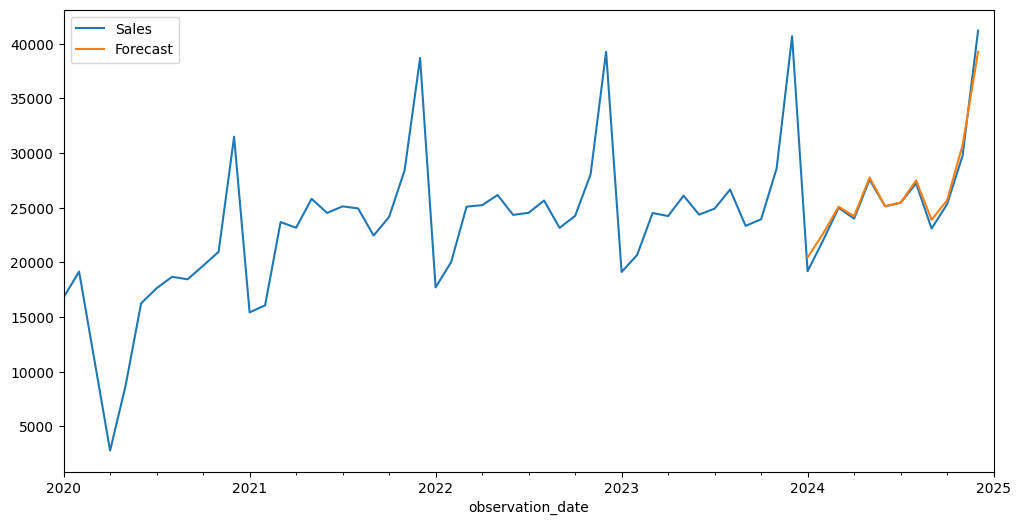

In [69]:
ax = df.plot(figsize=(12,6))
forecast_df.plot(ax=ax)
plt.xlim('2020-01-01','2025-01-01')
plt.show();

<html> <h2 style="font-style:bold; color:red;"> Lab Logbook requirements </h2> </html>

### 1. Record the 2nd model's code & plot the summary()

### 2. Copy your early-stop code and history_2 fit-training-process

### 3. Record the plot of validation and test loss of history_2.

### 4. Based on this analysis, determine the optimal number of epochs for training your model. 

### 5. Record the plot of the Checking Forecast for the last 12 months (last graph).

### Try the same example with a LSTM and/or GRU! (Optional)
Hint: Use LSTM instead of SimpleRNN!